## Cell 1: Environment Setup & Dependencies

In [1]:
# Core dependencies
import os
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from collections import defaultdict

# PyTorch & Vision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import MobileNetV2, mobilenet_v2

# Utilities
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ All imports successful")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

✓ All imports successful
✓ PyTorch version: 2.5.1+cu121
✓ CUDA available: True
✓ GPU: Quadro T1000


## Cell 2: Configuration & Path Setup

In [ ]:
# ============================================================================
# CONFIG
# ============================================================================
sys.path.insert(0, os.path.abspath(".."))
import config
class Config:
    # Dataset
    DATASET_ROOT = Path(config.KAGGLE_ASL_PATH)
    IMAGES_PER_CLASS = 9000 # Adjust based on actual dataset size
    IMAGE_SIZE = 128
    NUM_CLASSES = 29  # A-Z + DEL + NOTHING + SPACE
    
    # Model
    MODEL_NAME = "mobilenet_v2"
    PRETRAINED = True
    INPUT_CHANNELS = 3
    
    # Training
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 50
    WEIGHT_DECAY = 1e-4
    EARLY_STOPPING_PATIENCE = 10
    TRAIN_VAL_SPLIT = 0.8
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Paths
    PROJECT_ROOT = Path(config.BASE_DIR)
    MODELS_DIR = PROJECT_ROOT / "models" / "saved"
    LOGS_DIR = PROJECT_ROOT / "logs"
    RESULTS_DIR = PROJECT_ROOT / "results"
    
    # Output
    BEST_MODEL_PATH = MODELS_DIR / "best_model_mobilenet.pth"
    CHECKPOINT_PATH = MODELS_DIR / "checkpoint_mobilenet.pth"
    HISTORY_PATH = LOGS_DIR / f"training_history_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    
    # Reproducibility
    SEED = 42

# Create directories
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.LOGS_DIR.mkdir(parents=True, exist_ok=True)
Config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Set seeds
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"Dataset Root: {Config.DATASET_ROOT}")
print(f"Images per Class: {Config.IMAGES_PER_CLASS:,}")
print(f"Total Expected Images: {Config.IMAGES_PER_CLASS * Config.NUM_CLASSES:,}")
print(f"Image Size: {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}")
print(f"Batch Size: {Config.BATCH_SIZE}")
print(f"Learning Rate: {Config.LEARNING_RATE}")
print(f"Epochs: {Config.NUM_EPOCHS}")
print(f"Device: {Config.DEVICE}")
print(f"Best Model Path: {Config.BEST_MODEL_PATH}")
print("="*70 + "\n")


TRAINING CONFIGURATION
Dataset Root: C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\data\raw\kaggle_asl\ASL_Alphabet_Dataset\asl_alphabet_train
Images per Class: 9,000
Total Expected Images: 261,000
Image Size: 128×128
Batch Size: 64
Learning Rate: 0.001
Epochs: 50
Device: cuda
Best Model Path: C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\models\saved\best_model_mobilenet.pth



## Cell 3: Dataset Exploration & Class Mapping

In [3]:
# ============================================================================
# DATASET EXPLORATION
# ============================================================================

# Verify dataset exists
if not Config.DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset not found at {Config.DATASET_ROOT}")

print(f"Dataset root exists: {Config.DATASET_ROOT.exists()}")
print(f"\nDirectory structure:")
for item in sorted(Config.DATASET_ROOT.iterdir())[:10]:
    if item.is_dir():
        count = len(list(item.glob('*.jpg'))) + len(list(item.glob('*.png')))
        print(f"  {item.name}: {count} images")

# Build class mapping
class_dirs = sorted([d.name for d in Config.DATASET_ROOT.iterdir() if d.is_dir()])
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_dirs)}
idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}

print(f"\nClass Mapping ({len(class_to_idx)} classes):")
for idx, cls_name in sorted(idx_to_class.items()):
    print(f"  {idx:2d} -> {cls_name}")

# Count actual available images per class
print(f"\nImage count per class:")
class_counts = {}
for cls_name, cls_idx in class_to_idx.items():
    cls_path = Config.DATASET_ROOT / cls_name
    images = list(cls_path.glob('*.jpg')) + list(cls_path.glob('*.png'))
    class_counts[cls_name] = len(images)
    if len(images) > 0:
        print(f"  {cls_name:10s}: {len(images):4d} images")

total_images = sum(class_counts.values())
print(f"\nTotal images available: {total_images:,}")
print(f"Estimated RAM usage: ~{(total_images * 128 * 128 * 3) / (1024**3):.2f} GB (uncompressed)")

Dataset root exists: True

Directory structure:
  A: 7758 images
  B: 7609 images
  C: 7446 images
  D: 6929 images
  del: 6836 images
  E: 7044 images
  F: 7331 images
  G: 7144 images
  H: 7206 images
  I: 7253 images

Class Mapping (29 classes):
   0 -> A
   1 -> B
   2 -> C
   3 -> D
   4 -> E
   5 -> F
   6 -> G
   7 -> H
   8 -> I
   9 -> J
  10 -> K
  11 -> L
  12 -> M
  13 -> N
  14 -> O
  15 -> P
  16 -> Q
  17 -> R
  18 -> S
  19 -> T
  20 -> U
  21 -> V
  22 -> W
  23 -> X
  24 -> Y
  25 -> Z
  26 -> del
  27 -> nothing
  28 -> space

Image count per class:
  A         : 7758 images
  B         : 7609 images
  C         : 7446 images
  D         : 6929 images
  E         : 7044 images
  F         : 7331 images
  G         : 7144 images
  H         : 7206 images
  I         : 7253 images
  J         : 6803 images
  K         : 7176 images
  L         : 7239 images
  M         : 7200 images
  N         : 7232 images
  O         : 7440 images
  P         : 6901 images
  Q      

## Cell 4: Custom ASL Dataset Class

In [4]:
# ============================================================================
# CUSTOM DATASET
# ============================================================================

class ASLAlphabetDataset(Dataset):
    """
    Custom Dataset for ASL Alphabet images.
    Loads images with limit per class to avoid RAM overflow.
    """
    
    def __init__(
        self,
        root_dir,
        class_to_idx,
        images_per_class=2000,
        image_size=128,
        transform=None,
        indices=None  # For train/val split
    ):
        self.root_dir = Path(root_dir)
        self.class_to_idx = class_to_idx
        self.image_size = image_size
        self.transform = transform
        self.images_per_class = images_per_class
        
        self.image_paths = []
        self.labels = []
        self.class_names = list(class_to_idx.keys())
        
        # Load image paths with limit per class
        for cls_name, cls_idx in class_to_idx.items():
            cls_dir = self.root_dir / cls_name
            if not cls_dir.exists():
                print(f"Warning: Class directory not found: {cls_dir}")
                continue
            
            # Get all images
            all_images = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
            # Limit to images_per_class
            selected_images = all_images[:images_per_class]
            
            self.image_paths.extend(selected_images)
            self.labels.extend([cls_idx] * len(selected_images))
        
        # Apply indices for train/val split
        if indices is not None:
            self.image_paths = [self.image_paths[i] for i in indices]
            self.labels = [self.labels[i] for i in indices]
        
        print(f"Dataset initialized: {len(self.image_paths)} images loaded")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # Load image
            image = Image.open(img_path).convert('RGB')
            
            # Resize to fixed size
            image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
            
            # Apply transforms
            if self.transform:
                image = self.transform(image)
            else:
                image = transforms.ToTensor()(image)
            
            return image, label
        
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return black image as fallback
            return torch.zeros(3, self.image_size, self.image_size), label


print("✓ ASLAlphabetDataset class defined")

✓ ASLAlphabetDataset class defined


## Cell 5: Data Augmentation & Transforms

In [5]:
# ============================================================================
# DATA AUGMENTATION
# ============================================================================

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Data augmentation pipelines defined")
print(f"  Train transforms: {train_transform}")
print(f"  Val transforms: {val_transform}")

✓ Data augmentation pipelines defined
  Train transforms: Compose(
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
  Val transforms: Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Cell 6: Load Datasets & Create DataLoaders

In [6]:
# ============================================================================
# LOAD DATASETS
# ============================================================================

print("Loading datasets...")

# Create full dataset first
full_dataset = ASLAlphabetDataset(
    root_dir=Config.DATASET_ROOT,
    class_to_idx=class_to_idx,
    images_per_class=Config.IMAGES_PER_CLASS,
    image_size=Config.IMAGE_SIZE,
    transform=None  # We'll apply transforms per split
)

# Train/Val split
total_samples = len(full_dataset)
train_size = int(total_samples * Config.TRAIN_VAL_SPLIT)
val_size = total_samples - train_size

indices = torch.randperm(total_samples).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Create train/val datasets with transforms
train_dataset = ASLAlphabetDataset(
    root_dir=Config.DATASET_ROOT,
    class_to_idx=class_to_idx,
    images_per_class=Config.IMAGES_PER_CLASS,
    image_size=Config.IMAGE_SIZE,
    transform=train_transform,
    indices=train_indices
)

val_dataset = ASLAlphabetDataset(
    root_dir=Config.DATASET_ROOT,
    class_to_idx=class_to_idx,
    images_per_class=Config.IMAGES_PER_CLASS,
    image_size=Config.IMAGE_SIZE,
    transform=val_transform,
    indices=val_indices
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Total samples: {total_samples:,}")
print(f"Training samples: {train_size:,} ({Config.TRAIN_VAL_SPLIT*100:.0f}%)")
print(f"Validation samples: {val_size:,} ({(1-Config.TRAIN_VAL_SPLIT)*100:.0f}%)")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print("="*70 + "\n")

Loading datasets...
Dataset initialized: 204924 images loaded
Dataset initialized: 163939 images loaded
Dataset initialized: 40985 images loaded

DATASET SUMMARY
Total samples: 204,924
Training samples: 163,939 (80%)
Validation samples: 40,985 (20%)
Training batches: 2562
Validation batches: 641



## Cell 7: Build MobileNetV2 Model

In [ ]:
# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================

# Load pretrained MobileNetV2
model = mobilenet_v2(weights='DEFAULT')

# Get number of input features in classifier
num_features = model.classifier[1].in_features

# Replace classifier for our task
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(512, Config.NUM_CLASSES)
)

# Move to device
model = model.to(Config.DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
print(f"Model: MobileNetV2 (pretrained={Config.PRETRAINED})")
print(f"Input size: 3 × {Config.IMAGE_SIZE} × {Config.IMAGE_SIZE}")
print(f"Output classes: {Config.NUM_CLASSES}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {Config.DEVICE}")
print("="*70)
print(f"\nClassifier:\n{model.classifier}\n")


MODEL ARCHITECTURE
Model: MobileNetV2 (pretrained=True)
Input size: 3 × 128 × 128
Output classes: 29
Total parameters: 2,894,621
Trainable parameters: 2,894,621
Device: cuda

Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=512, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=512, out_features=29, bias=True)
)



## Cell 8: Loss Function & Optimizer

In [8]:
# ============================================================================
# LOSS & OPTIMIZER
# ============================================================================

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-7
)

print("✓ Loss function: CrossEntropyLoss")
print(f"✓ Optimizer: Adam (lr={Config.LEARNING_RATE}, decay={Config.WEIGHT_DECAY})")
print(f"✓ Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

✓ Loss function: CrossEntropyLoss
✓ Optimizer: Adam (lr=0.001, decay=0.0001)
✓ Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


## Cell 9: Training Functions

In [9]:
# ============================================================================
# TRAINING FUNCTIONS
# ============================================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{total_loss / (pbar.n + 1):.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


def validate(model, val_loader, criterion, device):
    """
    Validate the model.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validating", leave=False)
        
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Metrics
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({
                'loss': f'{total_loss / (pbar.n + 1):.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy, all_preds, all_labels


print("✓ Training and validation functions defined")

✓ Training and validation functions defined


## Cell 10: Main Training Loop

In [10]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

# Initialize tracking
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rates': []
}

best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0
best_epoch = 0

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70 + "\n")

start_time = datetime.now()

for epoch in range(Config.NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{Config.NUM_EPOCHS}]")
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, Config.DEVICE
    )
    
    # Validate
    val_loss, val_acc, _, _ = validate(
        model, val_loader, criterion, Config.DEVICE
    )
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rates'].append(current_lr)
    
    # Print metrics
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Learning Rate: {current_lr:.2e}")
    
    # Early stopping & model checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_epoch = epoch + 1
        patience_counter = 0
        
        # Save best model
        torch.save(model.state_dict(), Config.BEST_MODEL_PATH)
        print(f"  ✓ Best model saved (loss: {val_loss:.4f}, acc: {val_acc:.2f}%)")
    else:
        patience_counter += 1
        if patience_counter > Config.EARLY_STOPPING_PATIENCE:
            print(f"\n⚠ Early stopping triggered (patience: {Config.EARLY_STOPPING_PATIENCE})")
            break
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc
        }
        torch.save(checkpoint, Config.CHECKPOINT_PATH)
        print(f"  ✓ Checkpoint saved")

# Training complete
end_time = datetime.now()
elapsed = end_time - start_time

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"Total time: {elapsed}")
print(f"Best epoch: {best_epoch}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Best val accuracy: {best_val_acc:.2f}%")
print(f"Model saved to: {Config.BEST_MODEL_PATH}")
print("="*70 + "\n")


STARTING TRAINING


Epoch [1/50]


  Train Loss: 0.2057 | Train Acc: 93.93%
  Val Loss:   0.1053 | Val Acc:   96.78%
  Learning Rate: 1.00e-03
  ✓ Best model saved (loss: 0.1053, acc: 96.78%)

Epoch [2/50]


  Train Loss: 0.1025 | Train Acc: 97.06%
  Val Loss:   0.0907 | Val Acc:   97.27%
  Learning Rate: 1.00e-03
  ✓ Best model saved (loss: 0.0907, acc: 97.27%)

Epoch [3/50]


  Train Loss: 0.0840 | Train Acc: 97.65%
  Val Loss:   0.0488 | Val Acc:   98.56%
  Learning Rate: 1.00e-03
  ✓ Best model saved (loss: 0.0488, acc: 98.56%)

Epoch [4/50]


  Train Loss: 0.0765 | Train Acc: 97.86%
  Val Loss:   0.0664 | Val Acc:   97.98%
  Learning Rate: 1.00e-03

Epoch [5/50]


...

  Train Loss: 0.0196 | Train Acc: 99.45%
  Val Loss:   0.0101 | Val Acc:   99.71%
  Learning Rate: 5.00e-04

Epoch [23/50]


  Train Loss: 0.0196 | Train Acc: 99.44%
  Val Loss:   0.0088 | Val Acc:   99.72%
  Learning Rate: 5.00e-04

Epoch [24/50]


  Train Loss: 0.0187 | Train Acc: 99.49%
  Val Loss:   0.0089 | Val Acc:   99.73%
  Learning Rate: 5.00e-04

Epoch [25/50]


  Train Loss: 0.0209 | Train Acc: 99.42%
  Val Loss:   0.0086 | Val Acc:   99.78%
  Learning Rate: 5.00e-04

Epoch [26/50]


KeyboardInterrupt: 

## Cell 11: Evaluation on Validation Set

In [ ]:
# ============================================================================
# FINAL EVALUATION
# ============================================================================

# Load best model
best_model = mobilenet_v2(weights='DEFAULT')
best_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(512, Config.NUM_CLASSES)
)
best_model = best_model.to(Config.DEVICE)
best_model.load_state_dict(torch.load(Config.BEST_MODEL_PATH))

# Final validation
print("\nEvaluating best model on validation set...\n")
val_loss, val_acc, all_preds, all_labels = validate(
    best_model, val_loader, criterion, Config.DEVICE
)

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70 + "\n")

class_names_list = [idx_to_class[i] for i in range(Config.NUM_CLASSES)]
print(classification_report(all_labels, all_preds, target_names=class_names_list, digits=4))

# Overall metrics
print(f"\nOverall Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print("="*70 + "\n")


Evaluating best model on validation set...




CLASSIFICATION REPORT

              precision    recall  f1-score   support

           A     0.9980    0.9973    0.9977      1501
           B     0.9974    0.9954    0.9964      1513
           C     1.0000    1.0000    1.0000      1537
           D     0.9972    0.9993    0.9982      1422
           E     0.9938    0.9979    0.9958      1436
           F     0.9965    1.0000    0.9982      1425
           G     0.9951    1.0000    0.9976      1431
           H     1.0000    0.9960    0.9980      1492
           I     0.9993    1.0000    0.9997      1448
           J     0.9986    1.0000    0.9993      1380
           K     0.9986    0.9986    0.9986      1455
           L     1.0000    1.0000    1.0000      1479
           M     0.9979    0.9958    0.9968      1418
           N     0.9957    0.9978    0.9967      1383
           O     1.0000    0.9979    0.9990      1439
           P     1.0000    1.0000    1.0000      1375
           Q     0.9993    0.9993    0.9993      1430
   

## Cell 12: Confusion Matrix Visualization

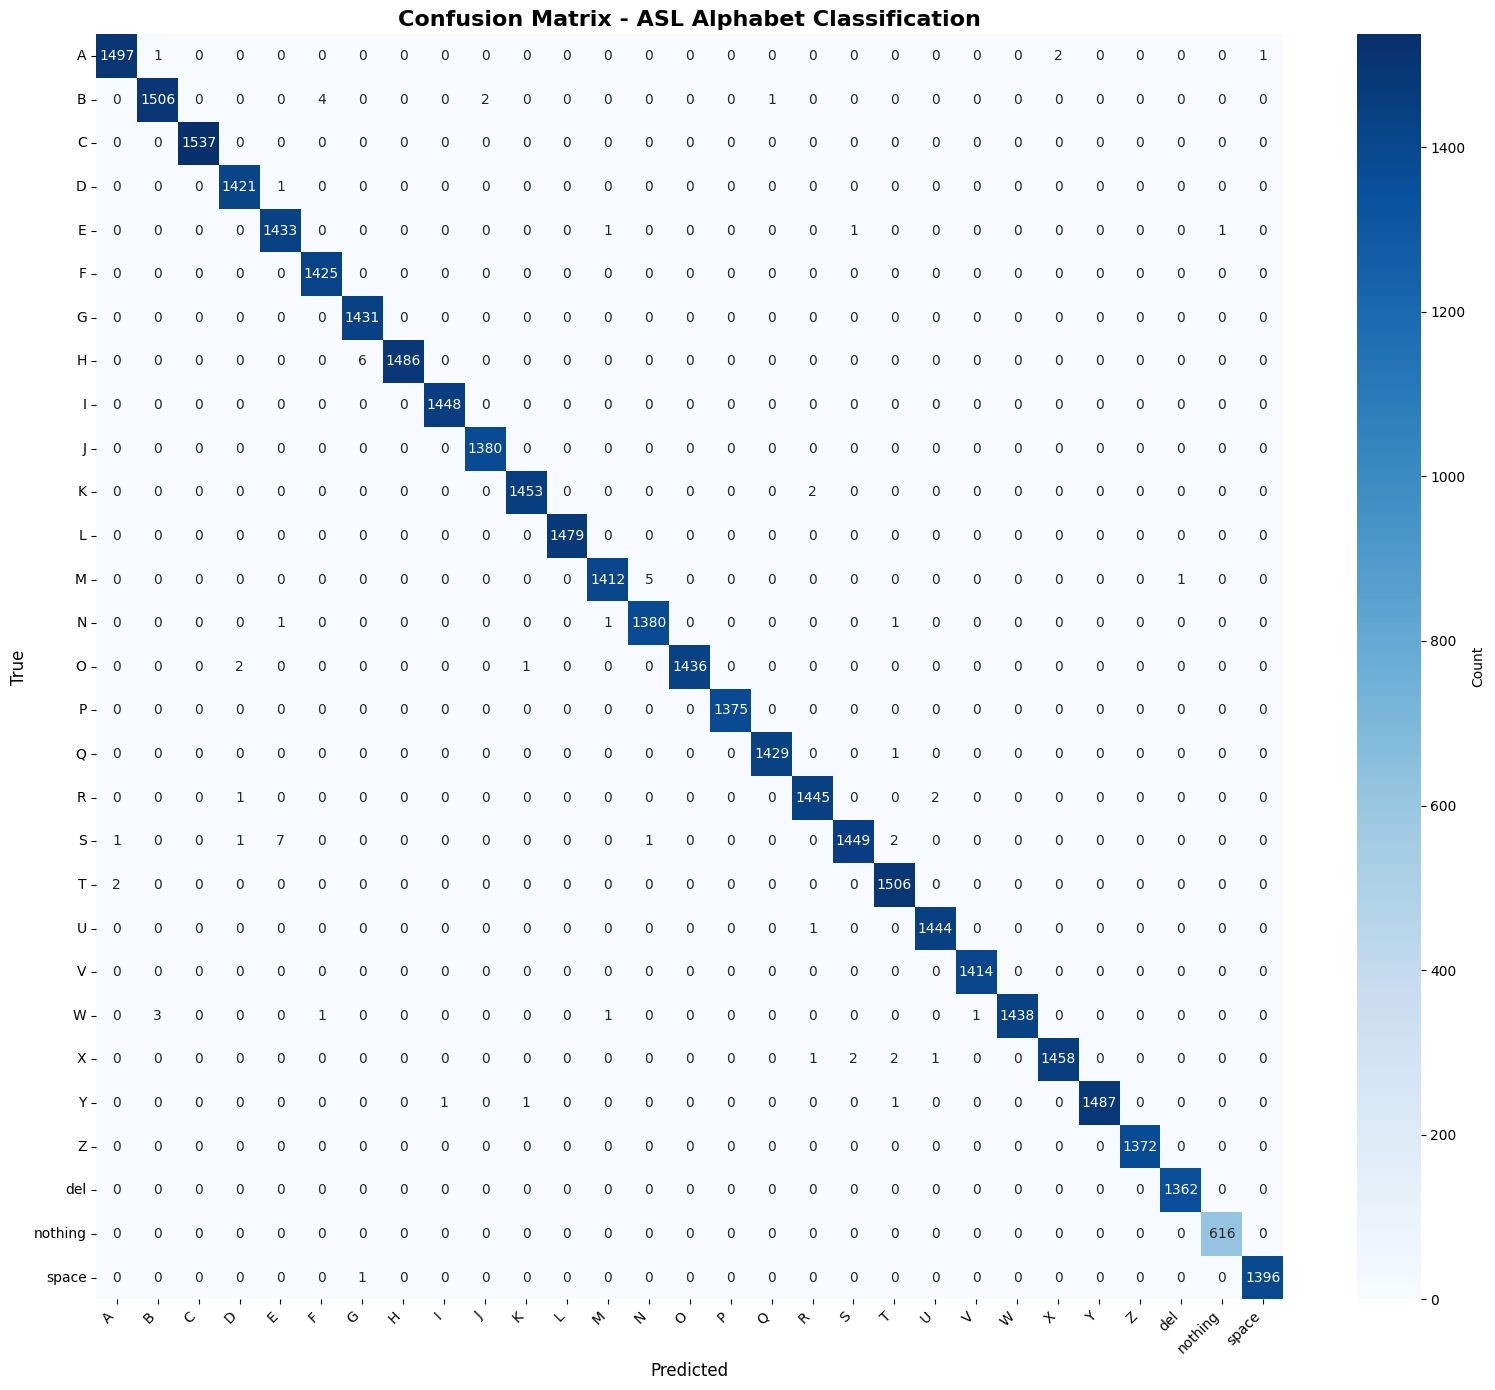

✓ Confusion matrix saved to C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\results\confusion_matrix.png


In [12]:
# ============================================================================
# CONFUSION MATRIX
# ============================================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names_list,
    yticklabels=class_names_list,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - ASL Alphabet Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(Config.RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved to {Config.RESULTS_DIR / 'confusion_matrix.png'}")

## Cell 13: Training History Visualization

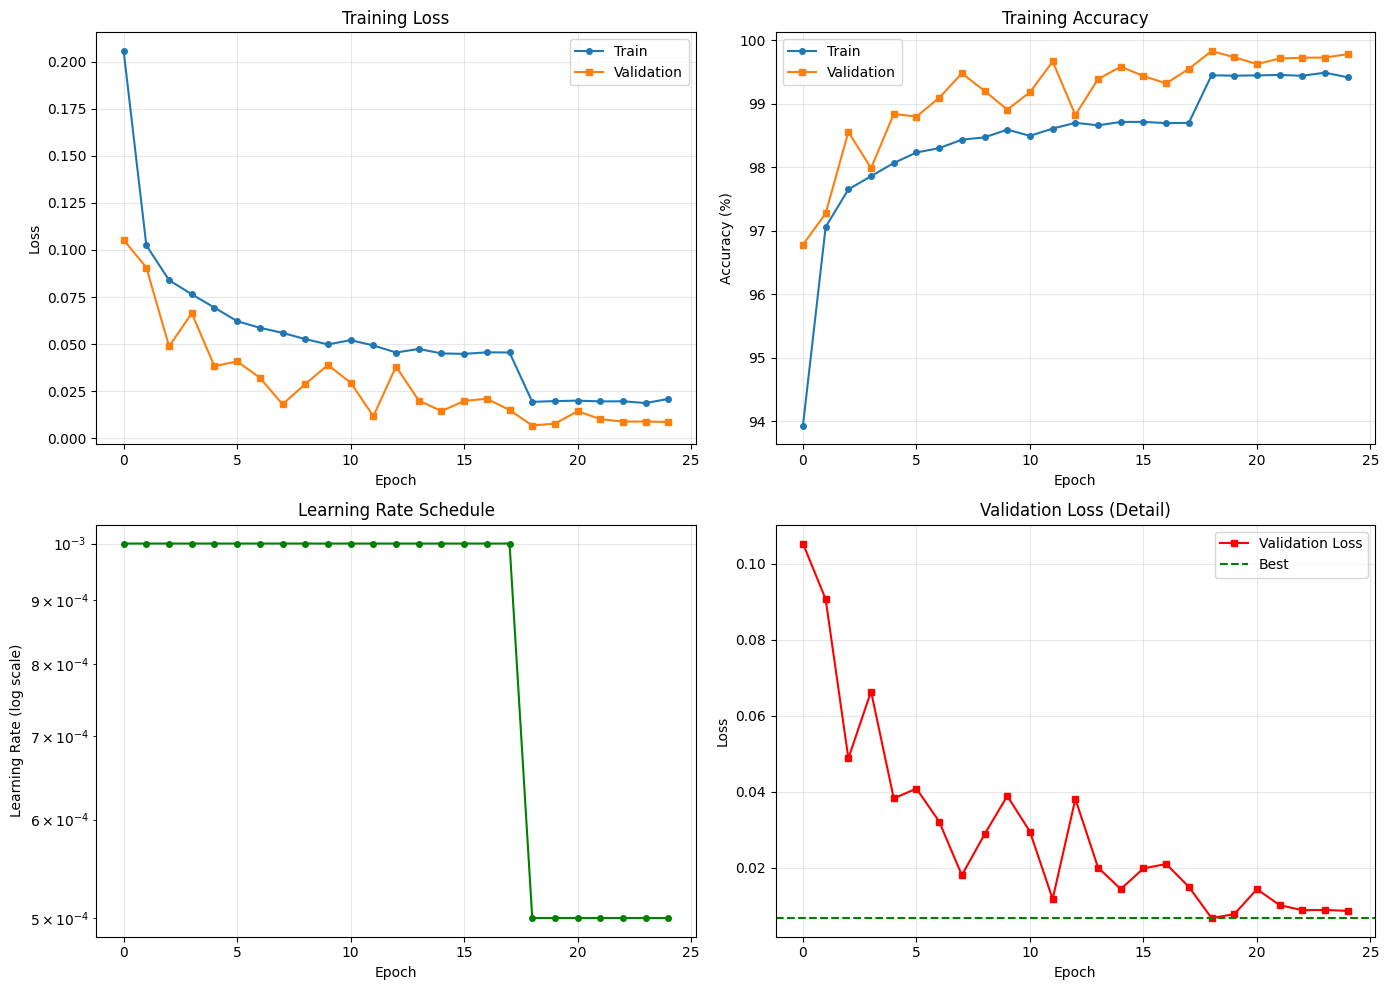

✓ Training history plots saved to C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\results\training_history.png


In [13]:
# ============================================================================
# TRAINING HISTORY PLOTS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=4)
axes[0, 0].plot(history['val_loss'], label='Validation', marker='s', markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train', marker='o', markersize=4)
axes[0, 1].plot(history['val_acc'], label='Validation', marker='s', markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 0].semilogy(history['learning_rates'], marker='o', markersize=4, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate (log scale)')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True, alpha=0.3)

# Val Loss (zoomed)
axes[1, 1].plot(history['val_loss'], label='Validation Loss', marker='s', markersize=4, color='red')
axes[1, 1].axhline(y=min(history['val_loss']), color='g', linestyle='--', label='Best')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Validation Loss (Detail)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Config.RESULTS_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Training history plots saved to {Config.RESULTS_DIR / 'training_history.png'}")

## Cell 14: Save Training Summary & History

In [15]:
# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save training history
elapsed = "Training manually stopped at Epoch 26"
with open(Config.HISTORY_PATH, 'w') as f:
    json.dump(history, f, indent=2)

# Save summary report
summary = {
    'model': 'MobileNetV2',
    'pretrained': Config.PRETRAINED,
    'num_classes': Config.NUM_CLASSES,
    'image_size': Config.IMAGE_SIZE,
    'batch_size': Config.BATCH_SIZE,
    'learning_rate': Config.LEARNING_RATE,
    'epochs_trained': len(history['train_loss']),
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'best_val_accuracy': float(best_val_acc),
    'final_val_accuracy': float(val_acc),
    'dataset': {
        'total_samples': len(full_dataset),
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'classes': Config.NUM_CLASSES,
        'images_per_class': Config.IMAGES_PER_CLASS
    },
    'model_path': str(Config.BEST_MODEL_PATH),
    'training_time': str(elapsed),
    'timestamp': datetime.now().isoformat()
}

summary_path = Config.RESULTS_DIR / f"training_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(json.dumps(summary, indent=2))
print("="*70)
print(f"\n✓ Summary saved to {summary_path}")
print(f"✓ History saved to {Config.HISTORY_PATH}")


TRAINING SUMMARY
{
  "model": "MobileNetV2",
  "pretrained": true,
  "num_classes": 29,
  "image_size": 128,
  "batch_size": 64,
  "learning_rate": 0.001,
  "epochs_trained": 25,
  "best_epoch": 19,
  "best_val_loss": 0.00674812613783296,
  "best_val_accuracy": 99.82920580700257,
  "final_val_accuracy": 99.82920580700257,
  "dataset": {
    "total_samples": 204924,
    "train_samples": 163939,
    "val_samples": 40985,
    "classes": 29,
    "images_per_class": 9000
  },
  "model_path": "C:\\Not Windows\\Artificial Intelligence and Machine Learning (AIM)\\Summer 2026\\Capstone Project\\models\\saved\\best_model_mobilenet.pth",
  "training_time": "Training manually stopped at Epoch 26",
  "timestamp": "2026-05-22T14:41:46.838192"
}

✓ Summary saved to C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\results\training_summary_20260522_144146.json
✓ History saved to C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\

## Cell 15: Model Export & Verification

In [ ]:
# ============================================================================
# MODEL VERIFICATION
# ============================================================================

# Verify model file
if Config.BEST_MODEL_PATH.exists():
    model_size = Config.BEST_MODEL_PATH.stat().st_size / (1024 * 1024) 
    print(f"\n✓ Model saved successfully")
    print(f"  Path: {Config.BEST_MODEL_PATH}")
    print(f"  Size: {model_size:.2f} MB")
else:
    print(f"\n✗ Model file not found at {Config.BEST_MODEL_PATH}")

# Quick test: load and run inference on a batch
print(f"\nVerifying model with inference test...")
test_model = mobilenet_v2(weights='DEFAULT')
test_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.2),
    nn.Linear(512, Config.NUM_CLASSES)
)
test_model.load_state_dict(torch.load(Config.BEST_MODEL_PATH))
test_model = test_model.to(Config.DEVICE)
test_model.eval()

# Get a test batch
test_images, test_labels = next(iter(val_loader))
test_images = test_images.to(Config.DEVICE)

with torch.no_grad():
    test_outputs = test_model(test_images)
    test_preds = test_outputs.argmax(dim=1)

print(f"✓ Inference successful on batch of {len(test_images)} images")
print(f"  Output shape: {test_outputs.shape}")
print(f"  Sample predictions: {test_preds[:5].cpu().numpy()}")

print("\n" + "="*70)
print("🎉 TRAINING PIPELINE COMPLETE")
print("="*70)
print(f"Best model: {Config.BEST_MODEL_PATH}")
print(f"Validation accuracy: {val_acc:.2f}%")
print("="*70)


✓ Model saved successfully
  Path: C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\models\saved\best_model_mobilenet.pth
  Size: 11.28 MB

Verifying model with inference test...
✓ Inference successful on batch of 64 images
  Output shape: torch.Size([64, 29])
  Sample predictions: [20 11  9 12 14]

🎉 TRAINING PIPELINE COMPLETE
Best model: C:\Not Windows\Artificial Intelligence and Machine Learning (AIM)\Summer 2026\Capstone Project\models\saved\best_model_mobilenet.pth
Validation accuracy: 99.83%
